# Optimal number of clusters

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data ingestion

In [3]:
def load_xai(run_id: str, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [4]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "unique_norm_weights": None,
        "norm_unique_norm_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["unique_norm_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["norm_weights"], n_segments=n_segments
    )

    data_dict["norm_unique_norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_norm_weights"]
    )

    return data_dict

## Clustering

In [5]:
def plot_inertias_silhouettes(
    inertias,
    silhouettes,
    n_clusters,
    figsize=(7, 4.5),
    subtitle="",
    rc_params: dict = {
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "figure.titlesize": 15,
        "lines.markersize": 4,
        "lines.linewidth": 1.5,
    }
):
    """
    Plot inertias and silhouette scores for different numbers of clusters.
    """
    with plt.rc_context(rc=rc_params):
        fig, axs = plt.subplots(2, 1, figsize=figsize, sharex=True)

        k_values = list(range(2, n_clusters))

        axs[0].plot(k_values, inertias, "-o", color="black")
        axs[1].plot(k_values, silhouettes, "-o", color="black")

        # Add major and minor ticks
        for ax in axs:
            ax.grid(True, which="major", linestyle="--", alpha=0.5, lw=0.6)
            ax.grid(True, which="minor", linestyle=":", alpha=0.3, lw=0.4)

        axs[1].set_xticks(k_values)

        axs[0].set_ylabel("Inertia")
        axs[1].set_ylabel("Silhouette Score")
        axs[1].set_xlabel("Number of Clusters ($k$)")
        if subtitle:
            fontsize = rc_params.get("figure.titlesize")
            axs[0].set_title(subtitle, fontsize=fontsize, pad=10)

    return fig, axs

## PCA

In [6]:
def pca_variance_analysis(X: np.ndarray, variance_threshold: float = 0.95):
    """
    Performs PCA on the input matrix and determines the number of components
    required to retain a specified amount of variance.

    Parameters
    ----------
    X : np.ndarray
        Input data matrix of shape (n_samples, n_features).
    variance_threshold : float
        The target cumulative explained variance (default is 0.95).

    Returns
    -------
    n_components_needed : int
        Number of PCA components needed to explain the desired variance.
    explained_variance_ratio : np.ndarray
        Cumulative explained variance ratio for each principal component.
    X_pca : np.ndarray
        Data projected into the PCA space (all components).
    """
    pca = PCA()
    X_pca = pca.fit_transform(X)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_components_needed = np.searchsorted(cumulative_variance, variance_threshold) + 1

    return n_components_needed, cumulative_variance, X_pca

In [7]:
def plot_pca_variance(
    cumulative_variance,
    n_components_needed,
    variance_threshold=0.95,
    figsize=(10, 6),
):
    """
    Plots the cumulative explained variance ratio from PCA.

    Parameters
    ----------
    cumulative_variance : np.ndarray
        Cumulative explained variance ratio for each principal component.
    n_components_needed : int
        Number of PCA components needed to explain the desired variance.
    variance_threshold : float
        The target cumulative explained variance (default is 0.95).
    """

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(cumulative_variance, marker="o", linestyle="--")

    ax.axhline(
        y=variance_threshold,
        color="r",
        linestyle="--",
        label=f"{variance_threshold:.0%} Variance Threshold",
    )

    ax.axvline(
        x=n_components_needed,
        color="g",
        linestyle="--",
        label=f"Components Needed: {n_components_needed}",
    )

    ax.set_title("PCA Cumulative Explained Variance")
    ax.set_xlabel("Number of Components")
    ax.set_ylabel("Cumulative Explained Variance Ratio")
    ax.legend()
    ax.grid()
    plt.tight_layout()
    return fig, ax

# Constants

## 343 segments run ids

In [8]:
run_ids_343_50k_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9'
}

In [9]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607200003_uniform_343_samples_100000_scale_0.9',
    'iforest': 'xai_202607201307_uniform_343_samples_100000_scale_0.9'
}

In [10]:
bin_id = "bin_03"
n_segments = 343
train_data_str = 'norm_unique_norm_weights'

# Config

## Directories

In [11]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

# Data prep

In [12]:
n_samples = 100_000

if n_samples == 100_000:
    run_ids_dict = run_ids_343_dict
elif n_samples == 50_000:
    run_ids_dict = run_ids_343_50k_dict

anomalies_all_dict = {}
specids_all_dict = {}
weights_all_dict = {}

for score_name, run_id in run_ids_dict.items():

    load_from = f"{explanations_dir}/{bin_id}/{score_name}"

    (
        anomalies_arr,
        specobjids_arr,
        weights_dict,
    ) = load_xai(run_id=run_id, load_from=load_from)

    anomalies_all_dict[score_name] = anomalies_arr
    specids_all_dict[score_name] = specobjids_arr
    weights_all_dict[score_name] = weights_prep(
        weights=weights_dict, n_segments=n_segments
    )

# SE Clustering

Run time: 4.00 seconds
Max silhouette score: 0.1886


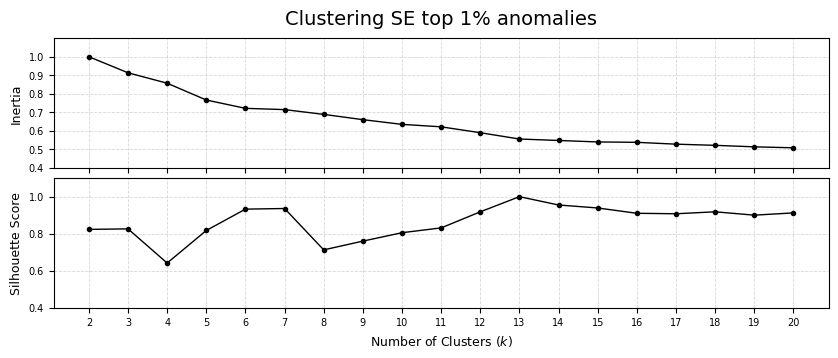

In [13]:
n_clusters = 21
X = weights_all_dict['mse'][train_data_str]

raw_inertias, raw_silhouette = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias_se = raw_inertias / np.max(raw_inertias)
max_silhouette = np.max(raw_silhouette)
print(f"Max silhouette score: {max_silhouette:.4f}")
silhouette_se = raw_silhouette / max_silhouette

rc_params = {
    # "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "figure.titlesize": 14,
    "lines.markersize": 3,
    "lines.linewidth": 1,
}

score_name = "SE"
subtitle = f"Clustering {score_name} top 1% anomalies"

fig, axs = plot_inertias_silhouettes(
    inertias=inertias_se,
    silhouettes=silhouette_se,
    figsize=(10, 3.5),
    n_clusters=inertias_se.shape[0] + 2,
    subtitle=subtitle,
    rc_params=rc_params
)

y_lims = (0.4, 1.1)
axs[0].set_ylim(y_lims)
y_ticks = np.arange(y_lims[0], y_lims[1], 0.1)
axs[0].set_yticks(y_ticks)

axs[1].set_ylim(y_lims)
y_ticks = np.arange(y_lims[0], y_lims[1], 0.2)
axs[1].set_yticks(y_ticks)


plt.subplots_adjust(hspace=0.08)
plt.show()
# # save fig
# fig.savefig(f"{ch_6_dir}/opt_n_cluster_{score_name}.pdf", bbox_inches="tight")

In [15]:
gain_se_inertia = (1-inertias_se) * 100
gain_se_inertia

array([ 0.        ,  8.6760257 , 14.3045599 , 23.38459835, 27.88147921,
       28.5641402 , 31.14749085, 33.99705244, 36.53732312, 37.86934309,
       41.05211123, 44.45337601, 45.24211284, 46.0389416 , 46.24546656,
       47.23595039, 47.86820422, 48.68220989, 49.19600955])

In [ ]:
gain_se_inertia[5] - gain_se_inertia[4], gain_se_inertia[11] - gain_se_inertia[4]

(np.float64(0.6826609840034692), np.float64(16.57189679582211))

## PCA

In [19]:
# X = weights_all_dict['mse']["norm_unique_weights"]
# print(f"data shape: {X.shape}")
# variance_threshold = 0.96
# n_components, cumvar, X_pca = pca_variance_analysis(X, variance_threshold)

# print(
#     "Number of components needed to explain "
#     f" {variance_threshold*100}% variance: {n_components}"
# )

# fig, ax = plot_pca_variance(
#     cumvar,
#     n_components,
#     variance_threshold=variance_threshold,
#     # figsize=(10, 6),
# )
# plt.show()

In [20]:
# X = weights_all_dict['mse']["norm_unique_weights"]
# variance_threshold = 0.99
# n_components, cumvar, X_pca = pca_variance_analysis(X, variance_threshold)
# print(f'N needed to explain {variance_threshold*100}% variance: {n_components}')
# n_clusters = 24
# n_top = weights_all_dict['mse']['weights'].shape[0]
# X = X_pca[:, :n_components]

# inertias, silhouette_scores = clustering.compute_inertias_silhouette(
#     X=X, n_clusters=n_clusters
# )

# inertias /= np.max(inertias)
# silhouette_scores /= np.max(silhouette_scores)

# subptitle = "SE top 1%"
# fig, axs = plot_inertias_silhouettes(
#     inertias=inertias,
#     silhouettes=silhouette_scores,
#     n_clusters=inertias.shape[0] + 2,
#     subtitle=subptitle,
# )
# plt.show()

# Filter SE

Run time: 4.37 seconds
Max silhouette score: 0.1900


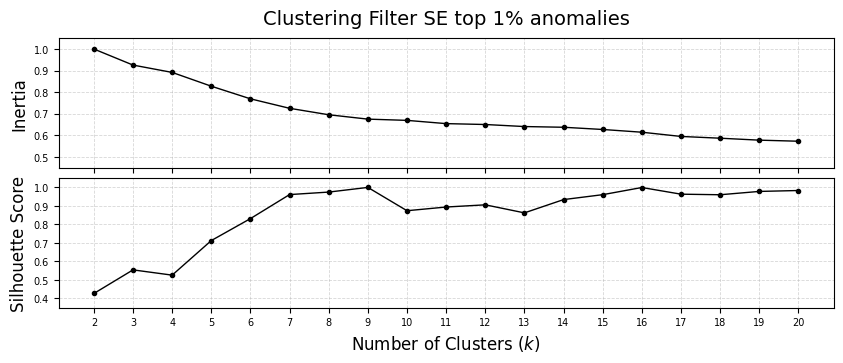

In [ ]:
# n_clusters = 21
# X = weights_all_dict['mse_filter_250'][train_data_str]

# raw_inertias, raw_silhouette = clustering.compute_inertias_silhouette(
#     X=X, n_clusters=n_clusters
# )

# inertias_filter_se = raw_inertias / np.max(raw_inertias)
# max_silhouette = np.max(raw_silhouette)
# print(f"Max silhouette score: {max_silhouette:.4f}")
# silhouette_filter_se = raw_silhouette / max_silhouette

# rc_params = {
#     # "font.family": "serif",
#     "font.size": 12,
#     "axes.labelsize": 12,
#     "xtick.labelsize": 7,
#     "ytick.labelsize": 7,
#     "figure.titlesize": 14,
#     "lines.markersize": 3,
#     "lines.linewidth": 1,
# }

# score_name = "Filter SE"
# subtitle = f"Clustering {score_name} top 1% anomalies"

# fig, axs = plot_inertias_silhouettes(
#     inertias=inertias_filter_se,
#     silhouettes=silhouette_filter_se,
#     figsize=(10, 3.5),
#     n_clusters=inertias_filter_se.shape[0] + 2,
#     subtitle=subtitle,
#     rc_params=rc_params
# )

# plt.subplots_adjust(hspace=0.08)
# plt.show()
# # # save fig
# # score_name = score_name.replace(" ", "_").lower()
# # fig.savefig(f"{ch_6_dir}/opt_n_cluster_{score_name}.pdf", bbox_inches="tight")

# Se + Filter SE single figure

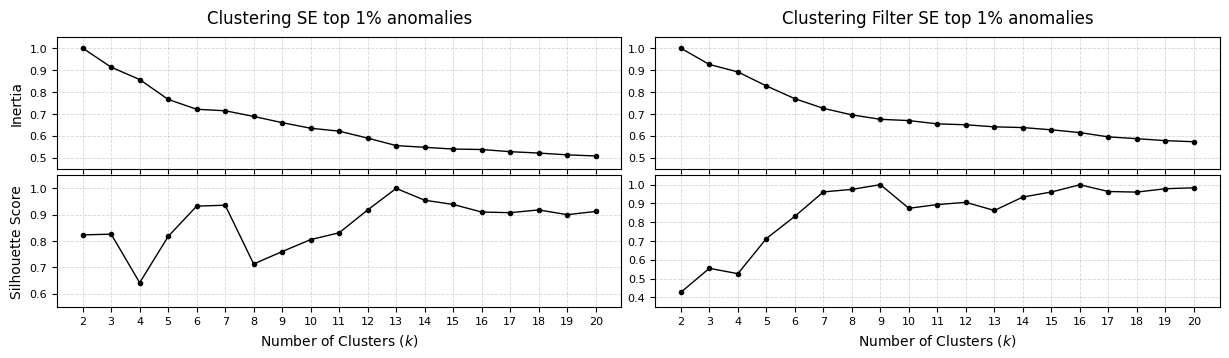

In [ ]:
# n_clusters = inertias_se.shape[0] + 2
# figsize = (15, 3.5)
# rc_params: dict = {
#     # "font.family": "serif",
#     "font.size": 10,
#     "axes.labelsize": 10,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "figure.titlesize": 12,
#     "lines.markersize": 3,
#     "lines.linewidth": 1.,
# }

# with plt.rc_context(rc=rc_params):
#     fig, axs = plt.subplots(2, 2, figsize=figsize, sharex=True)

#     k_values = list(range(2, n_clusters))

#     # SE
#     axs[0, 0].plot(
#         k_values, inertias_se, "-o", color="black"
#     )
#     axs[1, 0].plot(
#         k_values, silhouette_se, "-o", color="black"
#     )

#     # Filter SE
#     axs[0, 1].plot(
#         k_values, inertias_filter_se, "-o", color="black"
#     )
#     axs[1, 1].plot(
#         k_values, silhouette_filter_se, "-o", color="black"
#     )

#     # Add major and minor ticks
#     for ax in axs.flatten():
#         ax.grid(True, which="major", linestyle="--", alpha=0.5, lw=0.6)
#         ax.grid(True, which="minor", linestyle=":", alpha=0.3, lw=0.4)

#     for ax in axs[1, :]:
#         ax.set_xticks(k_values)

#     y0_min = np.floor(np.min(inertias_se) * 10) / 10
#     y0_ticks = np.arange(y0_min, 1.01, 0.1)
#     axs[0, 0].set_yticks(y0_ticks)
#     axs[0, 0].set_ylim(y0_min-0.05, 1.05)

#     y1_min = np.floor(np.min(silhouette_se) * 10) / 10
#     y1_ticks = np.arange(y1_min, 1.01, 0.1)
#     axs[1, 0].set_yticks(y1_ticks)
#     axs[1, 0].set_ylim(y1_min-0.05, 1.05)

#     y0_min = np.floor(np.min(inertias_filter_se) * 10) / 10
#     y0_ticks = np.arange(y0_min, 1.01, 0.1)
#     axs[0, 1].set_yticks(y0_ticks)
#     axs[0, 1].set_ylim(y0_min-0.05, 1.05)

#     y1_min = np.floor(np.min(silhouette_filter_se) * 10) / 10
#     y1_ticks = np.arange(y1_min, 1.01, 0.1)
#     axs[1, 1].set_yticks(y1_ticks)
#     axs[1, 1].set_ylim(y1_min-0.05, 1.05)

#     axs[0, 0].set_ylabel("Inertia")
#     axs[1, 0].set_ylabel("Silhouette Score")
#     axs[1, 0].set_xlabel("Number of Clusters ($k$)")
#     axs[1, 1].set_xlabel("Number of Clusters ($k$)")

#     fontsize = rc_params.get("figure.titlesize")

#     score_name = "SE"
#     subtitle = f"Clustering {score_name} top 1% anomalies"
#     axs[0, 0].set_title(subtitle, fontsize=fontsize, pad=10)

#     score_name = "Filter SE"
#     subtitle = f"Clustering {score_name} top 1% anomalies"
#     axs[0, 1].set_title(subtitle, fontsize=fontsize, pad=10)

# plt.subplots_adjust(hspace=0.05, wspace=0.06)
# plt.show()
# # # save fig
# score_name = 'se_filter_se'
# fig.savefig(f"{ch_6_dir}/opt_n_cluster_{score_name}.pdf", bbox_inches="tight")

# iForest

Run time: 4.19 seconds
Max silhouette score: 0.3026


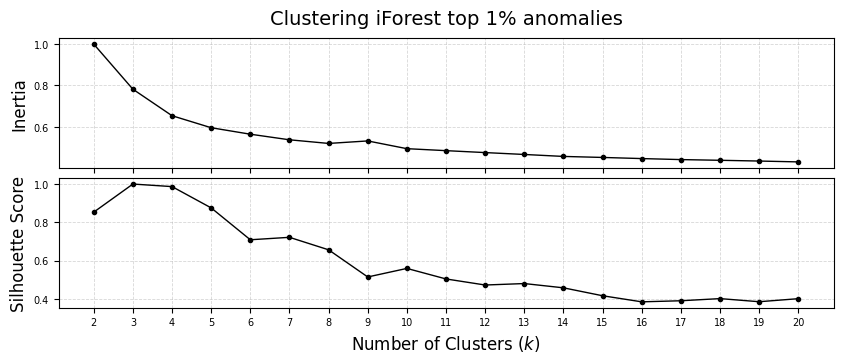

In [13]:
n_clusters = 21
X = weights_all_dict['iforest'][train_data_str]

raw_inertias, raw_silhouette = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias_iforest = raw_inertias / np.max(raw_inertias)
max_silhouette = np.max(raw_silhouette)
print(f"Max silhouette score: {max_silhouette:.4f}")
silhouette_iforest = raw_silhouette / max_silhouette

rc_params = {
    # "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "figure.titlesize": 14,
    "lines.markersize": 3,
    "lines.linewidth": 1,
}

score_name = "iForest"
subtitle = f"Clustering {score_name} top 1% anomalies"

fig, axs = plot_inertias_silhouettes(
    inertias=inertias_iforest,
    silhouettes=silhouette_iforest,
    figsize=(10, 3.5),
    n_clusters=inertias_iforest.shape[0] + 2,
    subtitle=subtitle,
    rc_params=rc_params
)

plt.subplots_adjust(hspace=0.08)
plt.show()
# # save fig
# score_name = score_name.lower()
# fig.savefig(f"{ch_6_dir}/opt_n_cluster_{score_name}.pdf", bbox_inches="tight")

# LOF

Run time: 4.11 seconds
Max silhouette score: 0.1682


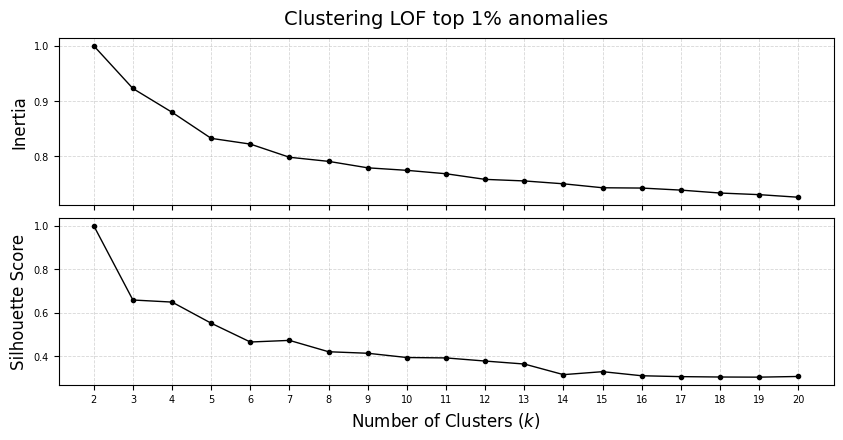

In [14]:
n_clusters = 21
X = weights_all_dict['lof'][train_data_str]

inertias, silhouette = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias_lof = inertias / np.max(inertias)
max_silhouette = np.max(silhouette)
print(f"Max silhouette score: {max_silhouette:.4f}")
silhouette_lof = silhouette / max_silhouette

rc_params = {
    # "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "figure.titlesize": 14,
    "lines.markersize": 3,
    "lines.linewidth": 1,
}

score_name = "LOF"
subtitle = f"Clustering {score_name} top 1% anomalies"

fig, axs = plot_inertias_silhouettes(
    inertias=inertias_lof,
    silhouettes=silhouette_lof,
    figsize=(10, 4.5),
    n_clusters=inertias_lof.shape[0] + 2,
    subtitle=subtitle,
    rc_params=rc_params
)

plt.subplots_adjust(hspace=0.08)
plt.show()
# # save fig
# score_name = score_name.lower()
# fig.savefig(f"{ch_6_dir}/opt_n_cluster_{score_name}.pdf", bbox_inches="tight")

## PCA

In [24]:
# X = weights_all_dict['lof']["norm_unique_weights"]
# print(f"data shape: {X.shape}")
# variance_threshold = 0.95
# n_components, cumvar, X_pca = pca_variance_analysis(X, variance_threshold)

# print(
#     "Number of components needed to explain "
#     f" {variance_threshold*100}% variance: {n_components}"
# )

# fig, ax = plot_pca_variance(
#     cumvar,
#     n_components,
#     variance_threshold=variance_threshold,
#     # figsize=(10, 6),
# )

# iForest + LOF

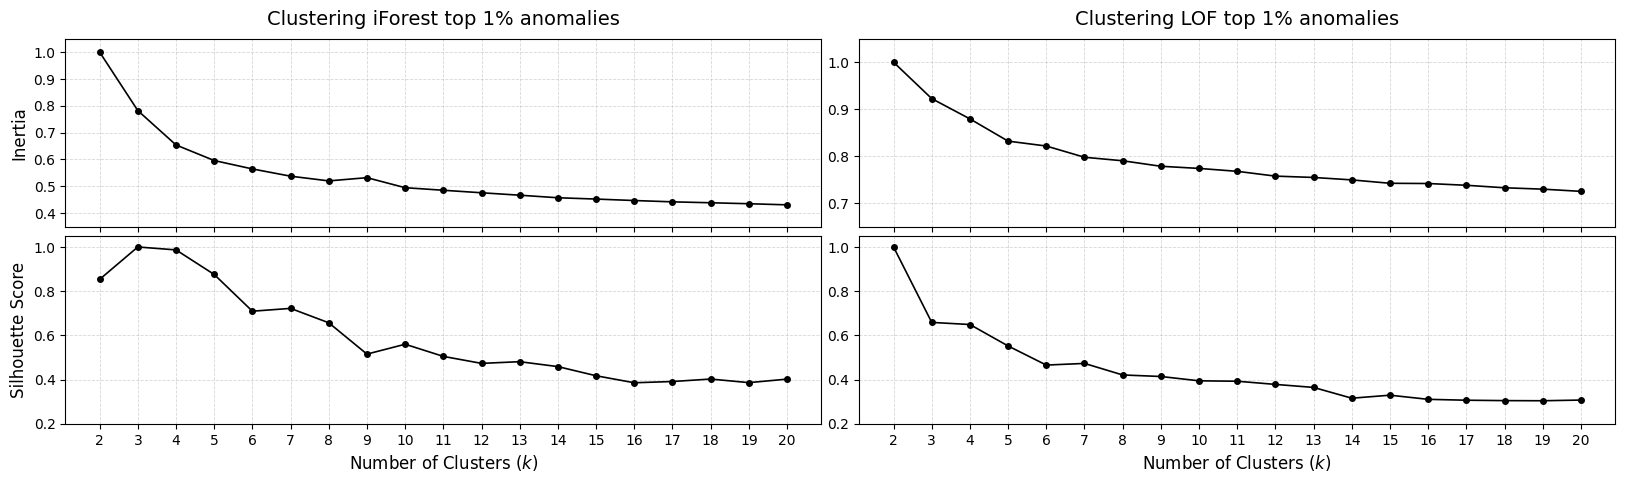

In [15]:
n_clusters = inertias_se.shape[0] + 2
figsize = (20, 5)
rc_params: dict = {
    # "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14,
    "lines.markersize": 4,
    "lines.linewidth": 1.2,
}

with plt.rc_context(rc=rc_params):
    fig, axs = plt.subplots(2, 2, figsize=figsize, sharex=True)

    k_values = list(range(2, n_clusters))

    # SE
    axs[0, 0].plot(
        k_values, inertias_iforest, "-o", color="black"
    )
    axs[1, 0].plot(
        k_values, silhouette_iforest, "-o", color="black"
    )

    # Filter SE
    axs[0, 1].plot(
        k_values, inertias_lof, "-o", color="black"
    )
    axs[1, 1].plot(
        k_values, silhouette_lof, "-o", color="black"
    )

    # Add major and minor ticks
    for ax in axs.flatten():
        ax.grid(True, which="major", linestyle="--", alpha=0.5, lw=0.6)
        ax.grid(True, which="minor", linestyle=":", alpha=0.3, lw=0.4)

    for ax in axs[1, :]:
        ax.set_xticks(k_values)
    # -------------------------------------------
    # Ticks
    y_lims = (0.35, 1.05)
    axs[0, 0].set_ylim(y_lims)
    y_ticks = np.arange(0.4, y_lims[1], 0.1)
    axs[0, 0].set_yticks(y_ticks)

    y_lims = (0.2, 1.05)
    axs[1, 0].set_ylim(y_lims)
    y_ticks = np.arange(0.2, y_lims[1], 0.2)
    axs[1, 0].set_yticks(y_ticks)
    # col 2
    y_lims = (0.65, 1.05)
    axs[0, 1].set_ylim(y_lims)
    y_ticks = np.arange(0.7, y_lims[1], 0.1)
    axs[0, 1].set_yticks(y_ticks)

    y_lims = (0.2, 1.05)
    axs[1, 1].set_ylim(y_lims)
    y_ticks = np.arange(0.2, y_lims[1], 0.2)
    axs[1, 1].set_yticks(y_ticks)

    # -------------------------------------------
    axs[0, 0].set_ylabel("Inertia")
    axs[1, 0].set_ylabel("Silhouette Score")
    axs[1, 0].set_xlabel("Number of Clusters ($k$)")
    axs[1, 1].set_xlabel("Number of Clusters ($k$)")

    fontsize = rc_params.get("figure.titlesize")

    score_name = "iForest"
    subtitle = f"Clustering {score_name} top 1% anomalies"
    axs[0, 0].set_title(subtitle, fontsize=fontsize, pad=10)

    score_name = "LOF"
    subtitle = f"Clustering {score_name} top 1% anomalies"
    axs[0, 1].set_title(subtitle, fontsize=fontsize, pad=10)

plt.subplots_adjust(hspace=0.05, wspace=0.05)
plt.show()
# save fig
score_name = 'iforest_lof'
fig.savefig(f"{ch_6_dir}/opt_n_cluster_{score_name}.pdf", bbox_inches="tight")

In [17]:
silhouette_iforest

array([0.85340626, 1.        , 0.9866787 , 0.875548  , 0.70922358,
       0.72200957, 0.65685275, 0.51509134, 0.55973998, 0.50475473,
       0.47312673, 0.48073633, 0.45849165, 0.41711355, 0.38538425,
       0.39100286, 0.40220988, 0.38596577, 0.40182888])

In [19]:
iforest_compactness_gain = (1 - inertias_iforest)*100
iforest_compactness_gain

array([ 0.        , 21.79612432, 34.60139442, 40.40427104, 43.53598711,
       46.23743749, 47.99377214, 46.78786559, 50.52662609, 51.48278196,
       52.4162986 , 53.32598733, 54.27540042, 54.76312521, 55.31020168,
       55.80006675, 56.14047227, 56.50351301, 56.91868112])

In [22]:
iforest_compactness_gain[3]- iforest_compactness_gain[6]

np.float64(-7.5895010941008465)

In [1]:
40.40 - 34.60

5.799999999999997